# 04 — Neural ODEs

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

In this notebook, we explore the connection between neural networks and differential equations. Neural ODEs learn a vector field that defines the dynamics of a system ([Chen et al., 2018](https://arxiv.org/abs/1806.07366)). This brings deep learning directly into the framework of dynamical systems and control.

### Table of Contents

1. **From ResNets to ODEs** — depth as continuous time
2. **Solving ODEs numerically** — Euler and Runge–Kutta methods
3. **Neural ODEs: learning dynamics** — we want to recover the law of motion behind an observed trajectory
4. **Neural ODEs: learning representations** — deforming the space with a flow until we get a better representation

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

# Reproducibility
rng = np.random.default_rng(0)
torch.manual_seed(0);

## 1. From residual networks to ODEs

**Idea.** A residual block looks like one numerical ODE step.

A **residual network** (ResNet; [He et al., 2016](https://arxiv.org/abs/1512.03385)) updates its hidden state $x_k \in \mathbb{R}^d$ by

$$x_{k+1} = x_k + f_{\theta_k}(x_k).$$

Compare this with the **explicit Euler method** for the ODE $\dot x = f_\theta(x)$ with step size $h$:

$$x_{k+1} = x_k + h\, f_\theta(x_k).$$

A residual update has the form of an Euler step. With suitable scaling and regularity, increasing the number of layers while $h \to 0$ connects the network to the **flow** of an ODE. This is the **neural ODE ansatz**:

$$\begin{cases}\dot x(t) = f_\theta\big(x(t)\big), \\ x(0) = x_{\text{in}}.\end{cases}$$

## 2. Solving ODEs numerically

**Idea.** Approximate a trajectory by taking small steps along its vector field.

Consider the initial value problem

$$\dot x(t) = f\big(t, x(t)\big), \qquad x(t_0) = x_0.$$

If $f$ is continuous in $t$ and Lipschitz in $x$, a unique solution exists on a neighborhood of $t_0$ (Picard–Lindelöf).

For many vector fields, a closed-form solution is unavailable, so we approximate the solution on a time grid $t_0 < t_1 < \dots < t_N$ with step size $h = t_{k+1} - t_k$ (constant for a uniform grid). The error orders below assume sufficient smoothness over a fixed time interval.

- **Explicit Euler** follows the tangent at the current point: $x_{k+1} = x_k + h\, f(t_k, x_k)$. Its accumulated global error is $\mathcal{O}(h)$.

- **Classical Runge–Kutta (RK4)** evaluates the slope four times per step and combines the evaluations:
$$
k_1 = f(t_k, x_k), \quad
k_2 = f\Big(t_k + \tfrac h2,\, x_k + \tfrac h2 k_1\Big), \quad
k_3 = f\Big(t_k + \tfrac h2,\, x_k + \tfrac h2 k_2\Big), \quad
k_4 = f(t_k + h,\, x_k + h k_3),
$$
$$x_{k+1} = x_k + \frac h6\big(k_1 + 2k_2 + 2k_3 + k_4\big),$$
with global error $\mathcal{O}(h^4)$.

**Code and plot.** Each stepper maps $(t_k, x_k)$ to $x_{k+1}$ exactly as in the formulas above; `odeint` chains steps along the grid and returns the whole trajectory. We compare both steppers on the Lorenz system below.

In [2]:
def euler_step(f, t, x, h):
    return x + h * f(t, x)

def rk4_step(f, t, x, h):
    k1 = f(t, x)
    k2 = f(t + h / 2, x + h / 2 * k1)
    k3 = f(t + h / 2, x + h / 2 * k2)
    k4 = f(t + h, x + h * k3)
    return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint(f, x0, ts, step=rk4_step):
    """Trajectory x(t_0), ..., x(t_N), stacked along the first axis (torch, so it stays differentiable)."""
    xs = [x0]
    for t0, t1 in zip(ts[:-1], ts[1:]):
        xs.append(step(f, t0, xs[-1], t1 - t0))
    return torch.stack(xs)

As a test problem, let us consider the **Lorenz system** ([Lorenz, 1963](https://doi.org/10.1175/1520-0469(1963)020%3C0130:DNF%3E2.0.CO;2))

$$\begin{cases}\dot x_1 = \sigma (x_2 - x_1), \\ \dot x_2 = x_1 (\rho - x_3) - x_2, \\ \dot x_3 = x_1 x_2 - \beta x_3,\end{cases}$$

with the classical parameters $\sigma = 10$, $\rho = 28$, $\beta = 8/3$, for which the dynamics are chaotic.

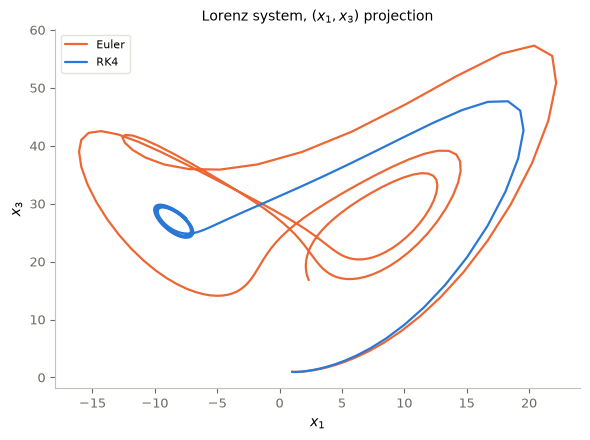

In [3]:
# Test problem: the Lorenz system, a chaotic 3-D flow
SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0

def f_lorenz(t, x):
    x1, x2, x3 = x[..., 0], x[..., 1], x[..., 2]
    return torch.stack([SIGMA * (x2 - x1), x1 * (RHO - x3) - x2, x1 * x2 - BETA * x3], dim=-1)

x0 = torch.tensor([1.0, 1.0, 1.0])
ts = torch.linspace(0, 3, 201)                  # h = 0.02
with torch.no_grad():
    tr_euler = odeint(f_lorenz, x0, ts, euler_step)
    tr_rk4 = odeint(f_lorenz, x0, ts, rk4_step)

fig, ax = P.panels(figsize=(6, 4.5))
P.phase(ax, [tr_euler[:, ::2], tr_rk4[:, ::2]], labels=["Euler", "RK4"], colors=[P.ORANGE, P.BLUE],
      xlabel="$x_1$", ylabel="$x_3$", title="Lorenz system, $(x_1, x_3)$ projection",
      legend={"loc": "upper left"})
plt.show()

## 3. Neural ODEs: learning dynamics

**Idea.** Learn the vector field from observed trajectories.

A neural ODE instead takes the right-hand side to be a small MLP,

$$\dot x = f_\theta(x), \qquad f_\theta : \mathbb{R}^3 \to \mathbb{R}^3 \ \text{a neural network},$$

which can approximate continuous vector fields on compact sets when its activation and width satisfy the universal approximation assumptions ([Hornik, 1991](https://doi.org/10.1016/0893-6080(91)90009-T)). Training then means fitting this vector field so that the trajectories it generates match the observed data.

**Code and plot.** Define a small vector field, train it on short trajectory segments, and compare a new trajectory with the true one.

In [4]:
# Vector field ansatz: a small MLP with tanh activations.
class VectorField(nn.Module):
    """The neural ODE ansatz: an MLP playing the role of the right-hand side."""
    def __init__(self, dim=2, width=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, dim),
        )
    def forward(self, t, x):          # same signature as every f used by odeint
        return self.net(x)

As training data, we generate a trajectory with RK4 and corrupt it with noise:

In [5]:
ts_lor = torch.linspace(0, 20, 2001)                # h = 0.01
with torch.no_grad():
    x_lor = odeint(f_lorenz, torch.tensor([1.0, 1.0, 1.0]), ts_lor)
    x_lor = x_lor + 0.1 * torch.randn_like(x_lor)

# Rescaled system: normalized state z = (x - mu) / sd, new time tau = 10 * t
mu, sd = x_lor.mean(0), x_lor.std(0)
z_lor, taus = (x_lor - mu) / sd, 10.0 * ts_lor

In [6]:
f_theta = VectorField(dim=3, width=128)
optimizer = torch.optim.Adam(f_theta.parameters(), lr=3e-3)

SEG, BATCH = 10, 64                   # window of 10 steps = 0.1 time units
for it in range(2001):
    for g in optimizer.param_groups:
        g["lr"] = 3e-3 * (1 - it / 2000)      # decay the step size linearly to zero
    i0 = torch.randint(0, len(taus) - SEG, (BATCH,))
    target = z_lor[i0[:, None] + torch.arange(SEG + 1)]
    pred = odeint(f_theta, z_lor[i0], taus[: SEG + 1])
    L = torch.mean((pred.transpose(0, 1) - target) ** 2)        # mean squared error over the window
    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    if it % 200 == 0:    
        print(f"iteration {it:3d}:  loss = {L.item():.4f}")

iteration   0:  loss = 0.1797


iteration 200:  loss = 0.0042


iteration 400:  loss = 0.0012


iteration 600:  loss = 0.0009


iteration 800:  loss = 0.0008


...

iteration 1200:  loss = 0.0004


iteration 1400:  loss = 0.0005


iteration 1600:  loss = 0.0005


iteration 1800:  loss = 0.0005


iteration 2000:  loss = 0.0004


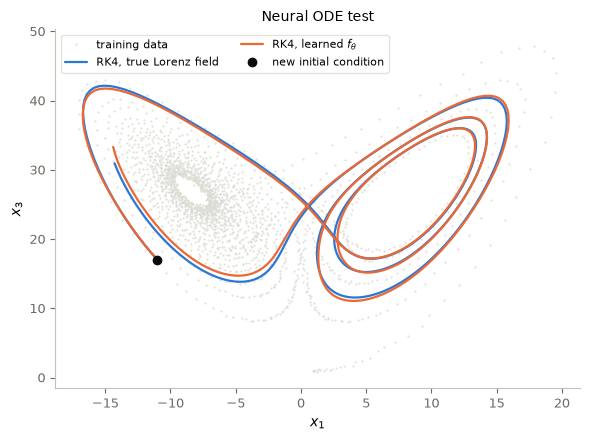

In [7]:
x0_new = torch.tensor([-11.0, -19.0, 17.0])         # near the attractor, but not a training point
ts_new = torch.linspace(0, 3, 501)
with torch.no_grad():
    tr_true = odeint(f_lorenz, x0_new, ts_new)      # ground truth: RK4 on the true Lorenz field
    tr_hat = mu + sd * odeint(f_theta, (x0_new - mu) / sd, 10 * ts_new)  # learned field, mapped back

fig, ax = P.panels(figsize=(6, 4.5))
ax.plot(x_lor[:, 0], x_lor[:, 2], ".", color=P.GHOST, ms=1, label="training data")
ax.plot(tr_true[:, 0], tr_true[:, 2], color=P.BLUE, label="RK4, true Lorenz field")
ax.plot(tr_hat[:, 0], tr_hat[:, 2], color=P.ORANGE, label=r"RK4, learned $f_\theta$")
ax.plot(x0_new[0], x0_new[2], "o", color=P.INK, ms=6, label="new initial condition")
P.label(ax, "$x_1$", "$x_3$", "Neural ODE test", legend={"loc": "upper left", "ncol": 2})
plt.show()

## 4. Neural ODEs: learning representations

**Idea.** Use a flow to move data into a representation that is easier to classify.

Our goal is to classify data using a neural ODE:

$$\text{logits}(x_{\text{in}}) := W\, x(1) + b, \qquad \dot x = f_\theta(x), \quad x(0) = x_{\text{in}},$$

trained with the cross-entropy loss. The final layer separates the classes with a **straight line**, so all of the geometric work has to be done by the flow: it must *deform the plane* until the two sets of points become linearly separable.

**Code and plot.** Train on two moons, then watch the learned flow move the points before classification.

In [8]:
def make_data(n_per_class=200, noise=0.08):        # as in notebook 01
    t = np.pi * rng.random(n_per_class)
    upper = np.stack([np.cos(t), np.sin(t)], axis=1)             # class 0
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)   # class 1
    X = np.concatenate([upper, lower]) + noise * rng.standard_normal((2 * n_per_class, 2))
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

X_data, y_data = make_data()
perm = torch.randperm(len(X_data))
tr_idx, te_idx = perm[:300], perm[300:]              # 75% train / 25% test

field = VectorField(width=32)                        # the flow's right-hand side
head = nn.Linear(2, 2)                               # affine readout on x(1)
ts_flow = torch.linspace(0, 1, 11)                   # T = 1, ten RK4 steps

def logits(x):
    return head(odeint(field, x, ts_flow)[-1])

optimizer = torch.optim.Adam(list(field.parameters()) + list(head.parameters()), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for it in range(501):
    L = loss_fn(logits(X_data[tr_idx]), y_data[tr_idx])
    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    if it % 100 == 0:
        with torch.no_grad():
            acc = (logits(X_data[te_idx]).argmax(dim=1) == y_data[te_idx]).float().mean()
        print(f"iteration {it:3d}:  loss = {L.item():.4f},  test accuracy = {acc:.1%}")

iteration   0:  loss = 0.8869,  test accuracy = 33.0%


iteration 100:  loss = 0.0138,  test accuracy = 99.0%


iteration 200:  loss = 0.0001,  test accuracy = 100.0%


iteration 300:  loss = 0.0000,  test accuracy = 100.0%


iteration 400:  loss = 0.0000,  test accuracy = 100.0%


iteration 500:  loss = 0.0000,  test accuracy = 100.0%


In [9]:
# The trajectory of EVERY data point under the learned flow
with torch.no_grad():
    flow_traj = odeint(field, X_data, torch.linspace(0, 1, 41)).numpy()   # (41, 400, 2)
    w = (head.weight[0] - head.weight[1]).numpy()                         # readout boundary w·x + b = 0
    b = (head.bias[0] - head.bias[1]).item()
colors = np.where(y_data.numpy() == 0, P.BLUE, P.ORANGE)

def readout_boundary(ax):
    x1 = np.array(ax.get_xlim())
    ax.plot(x1, -(w[0] * x1 + b) / w[1], "--", color=P.INK, lw=1.5)

P.animate_points(flow_traj, color=colors, decorate=readout_boundary, equal=False,
               figsize=(5.5, 4), xlabel="$x_1$", ylabel="$x_2$",
               title=lambda k: f"flow at $t = {k / 40:.2f}$", interval=120)

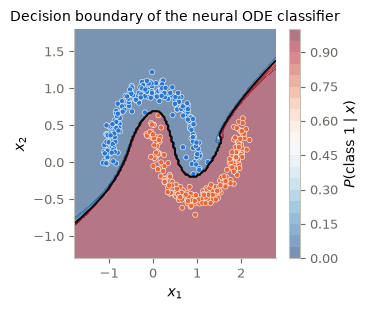

In [10]:
# Decision boundary back in INPUT space: grid points are flowed forward, then classified
g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 120), np.linspace(-1.3, 1.8, 120))
grid = torch.tensor(np.stack([g1.ravel(), g2.ravel()], axis=1), dtype=torch.float32)
with torch.no_grad():
    probs = torch.softmax(logits(grid), dim=1)[:, 1].reshape(g1.shape).numpy()

fig, ax = P.panels()
P.decision_boundary(ax, g1, g2, probs, X_data, y_data,
                  title="Decision boundary of the neural ODE classifier")
plt.show()

## Key takeaways

- A residual update has the form of an explicit Euler step.
- The solver turns a vector field into a trajectory; smaller steps trade more computation for accuracy.
- Training fits the vector field by differentiating a trajectory loss.
- For classification, the flow changes the representation before an affine readout separates the classes.

## Exercises

1. **Step size.** Halve the time-grid spacing in the Lorenz example. Plot the Euler and RK4 trajectories again. How does their difference change?
2. **Model size.** Reduce `VectorField` to one hidden layer of width 16. Compare the trajectory from a new initial condition with the true trajectory.
3. **Representation.** Plot the two-moons data at the start, halfway through the learned flow, and at the endpoint. Where do the classes become easier to separate?

## References

- K. He et al., [*Deep residual learning for image recognition*](https://arxiv.org/abs/1512.03385), CVPR, 2016.
- R. T. Q. Chen et al., [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366), NeurIPS, 2018.
- E. N. Lorenz, [*Deterministic nonperiodic flow*](https://doi.org/10.1175/1520-0469(1963)020%3C0130:DNF%3E2.0.CO;2), *Journal of the Atmospheric Sciences* **20** (1963), 130–141.
- K. Hornik, [*Approximation capabilities of multilayer feedforward networks*](https://doi.org/10.1016/0893-6080(91)90009-T), *Neural Networks* **4** (1991), 251–257.